In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, InceptionV3
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
# Define paths to your dataset
train_dir = r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train' # Update with your train directory path
val_dir = r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Validation'  # Update with your validation directory path

In [3]:
# Create an ImageDataGenerator for training and validation
train_datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values
val_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to the target size
    batch_size=32,
    class_mode='binary'  # Use 'binary' for two classes
)

Found 5291 images belonging to 2 classes.


In [5]:
# Load validation data
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),  # Resize images to the target size
    batch_size=32,
    class_mode='binary'  # Use 'binary' for two classes
)


Found 605 images belonging to 2 classes.


In [6]:

# Check the class indices
print("Class indices:", train_generator.class_indices)

Class indices: {'Peaceful': 0, 'Weaponized': 1}


## DATA EXPLORATION

Classes found: ['Peaceful', 'Weaponized']


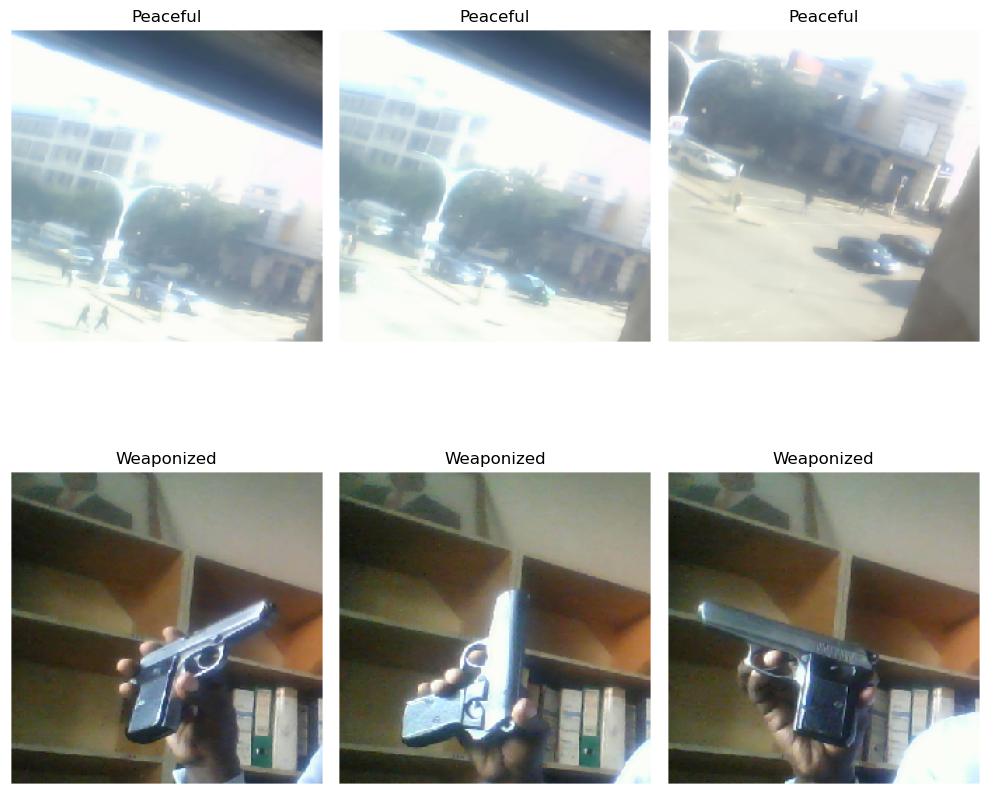

Total images sampled: 6

Class distribution:
Peaceful: 3 images
Weaponized: 3 images


In [8]:
import os

def explore_data(dataset_path, num_samples=3):
    # Get class names from the directory structure
    class_names = os.listdir(dataset_path)
    print("Classes found:", class_names)

    # Initialize a list to hold sample images and their labels
    samples = []
    labels = []

    # Load a sample of images from each class
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            # Get a list of all images in the class directory
            images = os.listdir(class_path)
            # Randomly select a few samples
            selected_images = np.random.choice(images, size=min(num_samples, len(images)), replace=False)
            for img_name in selected_images:
                img_path = os.path.join(class_path, img_name)
                img = load_img(img_path, target_size=(224, 224))  # Resize to the target size
                img_array = img_to_array(img) / 255.0  # Normalize the image
                samples.append(img_array)
                labels.append(class_name)

    # Convert to numpy array for easier manipulation
    samples = np.array(samples)
    labels = np.array(labels)

    # Plot sample images
    plt.figure(figsize=(10, 10))
    for i in range(min(num_samples * len(class_names), 9)):  # Display up to 9 images
        plt.subplot(len(class_names), num_samples, i + 1)
        plt.imshow(samples[i])
        plt.title(labels[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Display basic statistics
    print("Total images sampled:", len(samples))
    unique_labels, counts = np.unique(labels, return_counts=True)
    print("\nClass distribution:")
    for label, count in zip(unique_labels, counts):
        print(f"{label}: {count} images")

# Example usage
dataset_path = r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train'  # Update with your dataset path
explore_data(dataset_path, num_samples=3)

#### Sample Images from each class

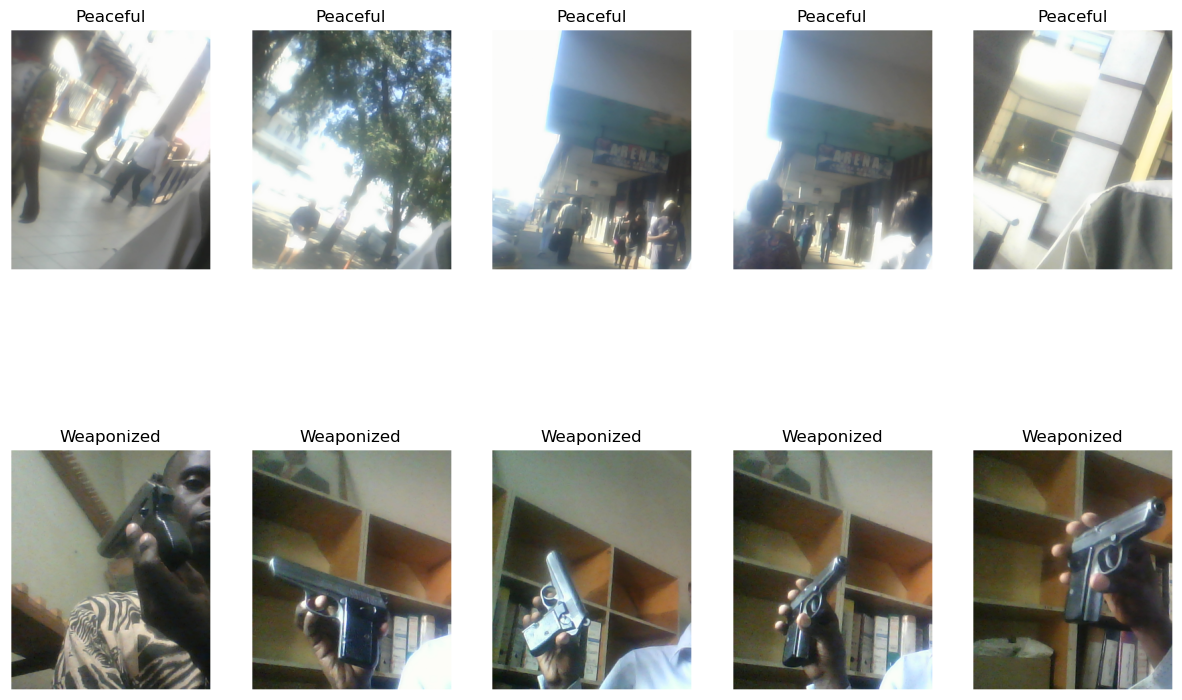

In [9]:
def plot_sample_images(data_directory, num_classes=2, samples_per_class=5):
    plt.figure(figsize=(15, 10))
    for class_name in os.listdir(data_directory)[:num_classes]:
        class_path = os.path.join(data_directory, class_name)
        images = os.listdir(class_path)
        sampled_images = random.sample(images, samples_per_class)
        
        for i, img_name in enumerate(sampled_images):
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)
            plt.subplot(num_classes, samples_per_class, i + 1 + (samples_per_class * list(os.listdir(data_directory)).index(class_name)))
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')
    plt.show()

# Call the function
plot_sample_images(r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train')

### Class Distribution

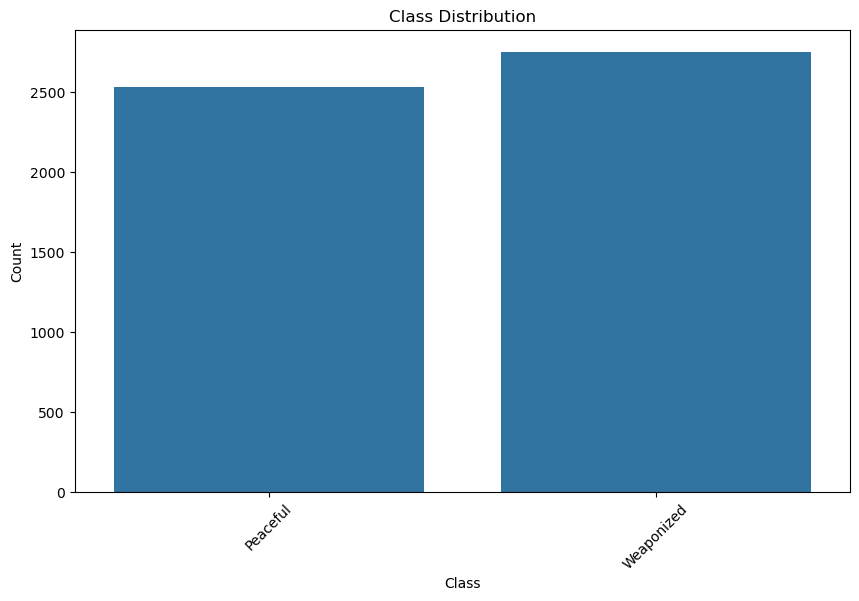

In [10]:
def class_distribution_plot(data_directory):
    class_names = os.listdir(data_directory)
    class_counts = [len(os.listdir(os.path.join(data_directory, class_name))) for class_name in class_names]
    
    df = pd.DataFrame({'Class': class_names, 'Count': class_counts})
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Class', y='Count', data=df)
    plt.title('Class Distribution')
    plt.xticks(rotation=45)
    plt.show()

# Call the function
class_distribution_plot(r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train')

## DATA PREPROCESSING


In [11]:
# Define paths to your dataset
train_dir = r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train'  # Update with your train directory path
val_dir = r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Validation'  # Update with your validation directory path

# Create ImageDataGenerators for training and validation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=20,  # Randomly rotate images in the range (degrees)
    width_shift_range=0.2,  # Randomly shift images horizontally (fraction of total width)
    height_shift_range=0.2,  # Randomly shift images vertically (fraction of total height)
    shear_range=0.2,  # Shear angle in counter-clockwise direction in degrees
    zoom_range=0.2,  # Randomly zoom into images
    horizontal_flip=True,  # Randomly flip images
    fill_mode='nearest'  # Fill in new pixels with the nearest pixel values
)

val_datagen = ImageDataGenerator(rescale=1./255)  # Only normalize for validation

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to the target size
    batch_size=32,
    class_mode='binary'  # Use 'binary' for two classes
)

# Load validation data
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),  # Resize images to the target size
    batch_size=32,
    class_mode='binary'  # Use 'binary' for two classes
)

# Check class indices
print("Class indices:", train_generator.class_indices)

Found 5291 images belonging to 2 classes.
Found 605 images belonging to 2 classes.
Class indices: {'Peaceful': 0, 'Weaponized': 1}


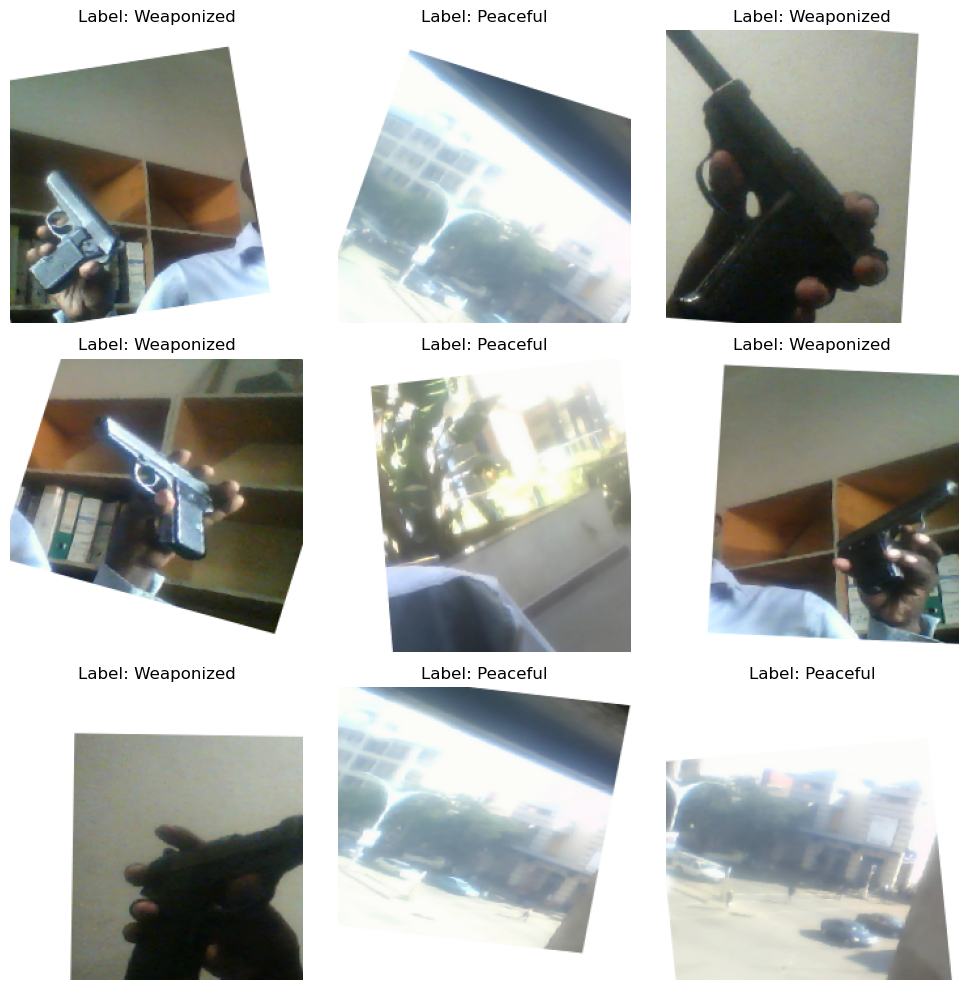

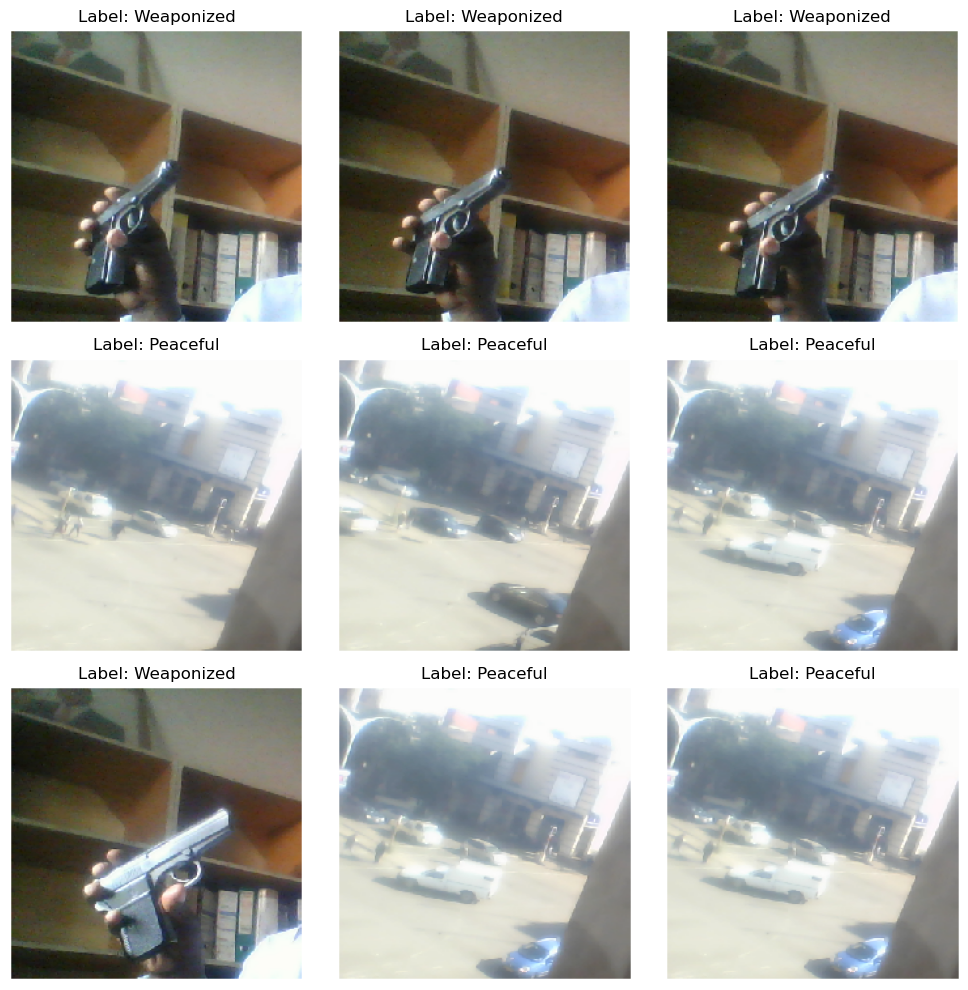

In [12]:
def preview_images(generator, num_images=9):
    # Get a batch of images and labels
    images, labels = next(generator)

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(min(num_images, images.shape[0])):  # Display up to num_images
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])  # Display the image
        plt.title('Label: {}'.format('Peaceful' if labels[i] == 0 else 'Weaponized'))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage
# Preview images from the training generator
preview_images(train_generator, num_images=9)

# Preview images from the validation generator
preview_images(val_generator, num_images=9)


### visualization of feature maps

## MODEL BUILDING

In [13]:
# Set up parameters
batch_size = 32
img_height, img_width = 224, 224  # Standard image size for models like VGG16, InceptionV3, and AlexNet

# Create an instance of ImageDataGenerator for training, validation, and testing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2  # 20% of training data for validation
)

In [14]:
# Generators
train_generator = train_datagen.flow_from_directory(
    r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train',  # Replace with your training data path
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # or 'categorical' for multi-class
    subset='training'  # Set as training data
)

Found 4234 images belonging to 2 classes.


In [15]:
val_generator = train_datagen.flow_from_directory(
    r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Train',  # Replace with your training data path
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'  # Set as validation data
)

Found 1057 images belonging to 2 classes.


In [16]:
test_datagen = ImageDataGenerator(rescale=1.0/255)  # Rescale for test data
test_generator = test_datagen.flow_from_directory(
    r'C:\Users\TinoL\Desktop\Taps\Firearms_Detection_Dataset\Test',  # Replace with your testing data path
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'  # or 'categorical' for multi-class
)


Found 40 images belonging to 2 classes.


In [17]:
# Define AlexNet Model
def create_alexnet_model(input_shape=(224, 224, 3)):
    model = models.Sequential()
    model.add(layers.Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
    model.add(layers.Conv2D(256, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
    model.add(layers.Conv2D(384, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(384, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))  # For binary classification
    return model

In [18]:
# Create and compile models
def create_and_compile_model(model_type):
    if model_type == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False
        model = models.Sequential([
            base_model,
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(1, activation='sigmoid')
        ])
    elif model_type == 'InceptionV3':
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dense(1, activation='sigmoid')
        ])
    elif model_type == 'AlexNet':
        model = create_alexnet_model()
    elif model_type == 'Custom CNN':
        model = create_custom_cnn_model()

    precision = Precision()
    recall = Recall()
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', precision, recall])
    return model

In [19]:
# Define Custom CNN Model (Example)
def create_custom_cnn_model(input_shape=(224, 224, 3)):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [20]:
# Function to plot t-SNE visualization
def plot_tsne(features, labels, model_name):
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    features_2d = tsne.fit_transform(features)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='viridis')
    plt.title(f't-SNE Visualization for {model_name}')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.colorbar(scatter, label='Class')
    plt.show()


In [21]:
# Extract features and plot t-SNE for each model
def extract_and_plot_tsne(model_type, test_generator):
    model = create_and_compile_model(model_type)
    try:
        model.load_weights(f'{model_type}_weights.h5')  # Load trained weights if saved
    except FileNotFoundError:
        print(f"Weights for {model_type} not found. Please train the model first.")
        return
    feature_extractor = models.Model(inputs=model.input, outputs=model.layers[-2].output)  # Get penultimate layer
    features = feature_extractor.predict(test_generator)
    plot_tsne(features, test_generator.classes, model_type)

In [22]:
# Model types for analysis
model_types = ['VGG16', 'InceptionV3', 'AlexNet', 'Custom CNN']

# Train models and store histories
histories = {}

for model_type in model_types:
    model = create_and_compile_model(model_type)
    print(f'Training {model_type}...')
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        epochs=4
    )
    
    # Save model weights after training
    model.save_weights(f'{model_type}_weights.h5')
    
    histories[model_type] = history

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Training VGG16...
Epoch 1/4


c:\ProgramData\anaconda3\envs\ML-py\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


132/132 ━━━━━━━━━━━━━━━━━━━━ 1744s 13s/step - accuracy: 0.9216 - loss: 0.2642 - precision: 0.9216 - recall: 0.9279 - val_accuracy: 0.9848 - val_loss: 0.0272 - val_precision: 0.9717 - val_recall: 1.0000
Epoch 2/4
  1/132 ━━━━━━━━━━━━━━━━━━━━ 21:01 10s/step - accuracy: 1.0000 - loss: 1.1186e-05 - precision: 1.0000 - recall: 1.0000

c:\ProgramData\anaconda3\envs\ML-py\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


132/132 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 1.0000 - loss: 1.1186e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 3.7990e-07 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/4
132/132 ━━━━━━━━━━━━━━━━━━━━ 1101s 8s/step - accuracy: 1.0000 - loss: 2.9829e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9621 - val_loss: 0.0862 - val_precision: 0.9321 - val_recall: 1.0000
Epoch 4/4
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 1.0000 - loss: 7.1322e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.5813e-09 - val_precision: 1.0000 - val_recall: 1.0000


ValueError: The filename must end in `.weights.h5`. Received: filepath=VGG16_weights.h5

In [23]:
# Generate t-SNE plots after training
for model_type in model_types:
    extract_and_plot_tsne(model_type, test_generator)

# Function to evaluate the model
def evaluate_model(model, test_generator):
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
    
    # Get predictions
    y_true = test_generator.classes
    y_pred_probs = model.predict(test_generator)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    # Calculate precision, recall, and F1 score
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return test_loss, test_accuracy, precision, recall, f1, y_true, y_pred_probs


Weights for VGG16 not found. Please train the model first.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Weights for InceptionV3 not found. Please train the model first.


c:\ProgramData\anaconda3\envs\ML-py\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Weights for AlexNet not found. Please train the model first.
Weights for Custom CNN not found. Please train the model first.


In [ ]:
# Evaluate all models and store results
results = {}
for model_type in model_types:
    model = create_and_compile_model(model_type)
    model.load_weights(f'{model_type}_weights.h5')  # Load trained weights if saved
    print(f'Evaluating {model_type}...')
    results[model_type] = evaluate_model(model, test_generator)

# Print the results
for model_name, metrics in results.items():
    test_loss, test_accuracy, precision, recall, f1, y_true, y_pred_probs = metrics
    print(f"{model_name} - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, "
          f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

In [89]:
# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [90]:
# Function to plot ROC curve
def plot_roc_curve(y_true, y_pred_probs, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()


In [ ]:
# Function to plot learning curves
def plot_learning_curves(histories):
    plt.figure(figsize=(18, 8))

    # Accuracy
    plt.subplot(1, 2, 1)
    for model_name, history in histories.items():
        plt.plot(history.history['accuracy'], label=f'{model_name} Train Accuracy')
        plt.plot(history.history['val_accuracy'], label=f'{model_name} Val Accuracy', linestyle='--')
    plt.title('Model Accuracy Learning Curves')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(1, 2, 2)
    for model_name, history in histories.items():
        plt.plot(history.history['loss'], label=f'{model_name} Train Loss')
        plt.plot(history.history['val_loss'], label=f'{model_name} Val Loss', linestyle='--')
    plt.title('Model Loss Learning Curves')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Plot learning curves for all models
plot_learning_curves(histories)

In [ ]:
# Plot confusion matrices and ROC curves
for model_name, metrics in results.items():
    _, _, _, _, _, y_true, y_pred_probs = metrics
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    plot_confusion_matrix(y_true, y_pred, model_name)
    plot_roc_curve(y_true, y_pred_probs, model_name)

## MODEL TESTING

In [ ]:
# Function to evaluate the model
def evaluate_model(model, test_generator):
    # Evaluate the model on the test set
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
    
    # Get predictions
    y_true = test_generator.classes
    y_pred_probs = model.predict(test_generator)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions
    
    # Calculate precision, recall, and F1 score
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return test_loss, test_accuracy, precision, recall, f1

# Evaluate all models and store results
results = {}

# Assuming 'test_generator' is defined and ready
for model_type in model_types:
    model = create_and_compile_model(model_type)  # Recreate the model if not already in memory
    model.load_weights(f'{model_type}_weights.h5')  # Load the trained weights if saved
    print(f'Evaluating {model_type}...')
    results[model_type] = evaluate_model(model, test_generator)

In [ ]:
# Print the results
for model_name, metrics in results.items():
    test_loss, test_accuracy, precision, recall, f1 = metrics
    print(f"{model_name} - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, "
          f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")